##Importações básicas

In [1]:
!pip install numpy scikit-learn pandas torch matplotlib seaborn
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Defaulting to user installation because normal site-packages is not writeable


#Regressão

Na tarefa dessa semana, iremos explorar aplicações de modelos de regressão. Diferente de modelos de classificação, onde desejamos descobrir a qual classe pertence uma amostra com base nos outros dados fornecidos, os modelos de regressão nos retornam um valor numérico.

Realize a aplicação das técnicas apresentadas a seguir e, por fim, escreva uma breve conclusão comparando os resultados obtidos entre os modelos utilizando as diferentes métricas de avaliação.


Materiais de apoio:

*   https://ricardomatsumura.medium.com/aprendizado-supervisionado-regress%C3%A3o-363547528ce5
*   https://www.geeksforgeeks.org/regression-in-machine-learning/

## Baixar dataset

O conjunto utilizado nesta tarefa está disponível no seguinte link:

https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv

Pesquise como utilizar um conjunto de dados tabular disponibilizado no github. É uma tarefa bem simples, então você não deverá ter problemas.

Além disso, verifique a qualidade do dataset e veja se é necessário realizar alguma forma de tratamento de dados.

In [2]:
os.system('rm -f insurance.csv')
!wget https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv

df = pd.read_csv('insurance.csv')

print(df.head())
print('\nFormato:', df.shape)
print('\nTipos:\n', df.dtypes)
print('\nValores nulos:\n', df.isnull().sum())
print('\nEstatísticas:\n')
df.describe()



7[Files: 0  Bytes: 0  [0 B/s] Re]87[https://raw.githubusercontent.]87Saving 'insurance.csv'
87insurance.csv        100% [=============================>]   15.36K    --.-KB/s87HTTP response 200  [https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv]
87insurance.csv        100% [=============================>]   15.36K    --.-KB/s87[Files: 1  Bytes: 15.36K [41.18]8   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Formato: (1338, 7)

Tipos:
 age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Valores nu

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [3]:
le = LabelEncoder()
df['sex']    = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])

X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Treino: {X_train_s.shape[0]} amostras | Teste: {X_test_s.shape[0]} amostras')

Treino: 1070 amostras | Teste: 268 amostras


##Regressão Linear

Materiais de apoio:

*   https://scikit-learn.org/stable/modules/linear_model.html#ordinary-least-squares



MAE:  4186.51
MSE:  33635210.43
RMSE: 5799.59
R²:   0.7833


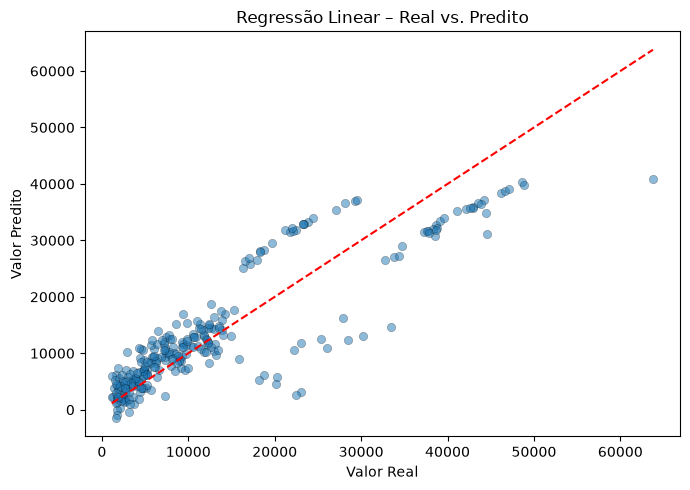

In [4]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_s, y_train)

y_pred_lr = lr.predict(X_test_s)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
mse_lr  = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

print(f'MAE:  {mae_lr:.2f}')
print(f'MSE:  {mse_lr:.2f}')
print(f'RMSE: {rmse_lr:.2f}')
print(f'R²:   {r2_lr:.4f}')

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_lr, alpha=0.5, edgecolors='k', linewidths=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Valor Real')
plt.ylabel('Valor Predito')
plt.title('Regressão Linear – Real vs. Predito')
plt.tight_layout()
plt.show()

##SVR - Support Vector Regression

Materiais de apoio:


*   https://scikit-learn.org/stable/modules/svm.html#regression


MAE:  1888.58
MSE:  19829075.77
RMSE: 4452.99
R²:   0.8723


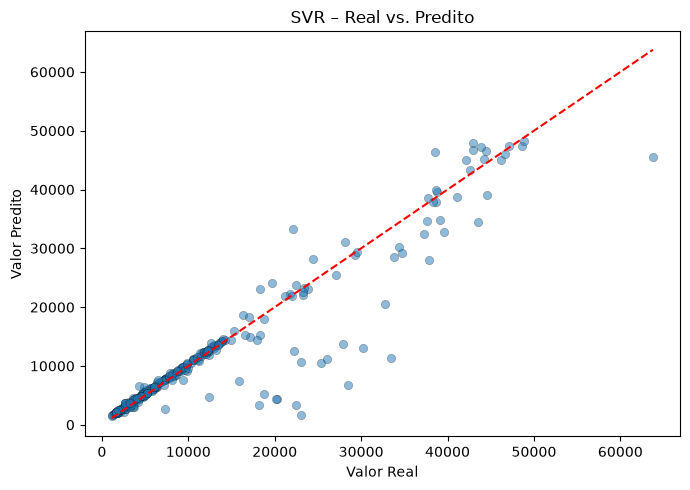

In [5]:
from sklearn.svm import SVR

svr = SVR(kernel='rbf', C=100000, epsilon=500)
svr.fit(X_train_s, y_train)

y_pred_svr = svr.predict(X_test_s)

mae_svr  = mean_absolute_error(y_test, y_pred_svr)
mse_svr  = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
r2_svr   = r2_score(y_test, y_pred_svr)

print(f'MAE:  {mae_svr:.2f}')
print(f'MSE:  {mse_svr:.2f}')
print(f'RMSE: {rmse_svr:.2f}')
print(f'R²:   {r2_svr:.4f}')

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_svr, alpha=0.5, edgecolors='k', linewidths=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Valor Real')
plt.ylabel('Valor Predito')
plt.title('SVR – Real vs. Predito')
plt.tight_layout()
plt.show()

## MLP (sklearn)

Materiais de apoio:


*   https://scikit-learn.org/stable/modules/neural_networks_supervised.html#regression



MAE:  2540.97
MSE:  19166820.97
RMSE: 4377.99
R²:   0.8765


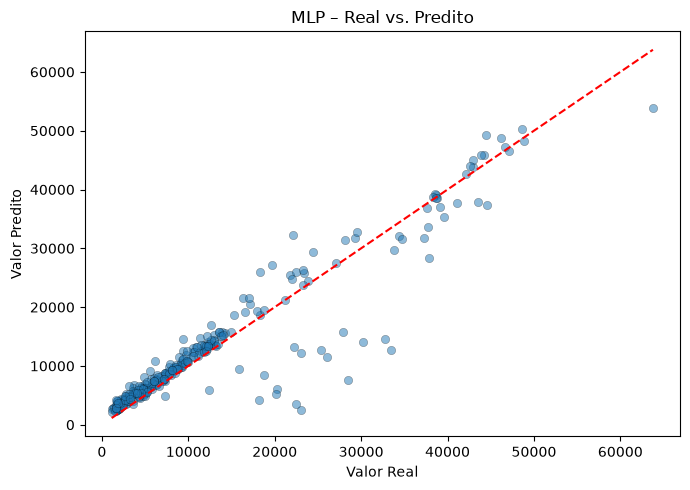

In [8]:
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(
    hidden_layer_sizes=(256, 128, 64),
    max_iter=2000,
    random_state=42,
    early_stopping=True
)
mlp.fit(X_train_s, y_train)

y_pred_mlp = mlp.predict(X_test_s)

mae_mlp  = mean_absolute_error(y_test, y_pred_mlp)
mse_mlp  = mean_squared_error(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mse_mlp)
r2_mlp   = r2_score(y_test, y_pred_mlp)

print(f'MAE:  {mae_mlp:.2f}')
print(f'MSE:  {mse_mlp:.2f}')
print(f'RMSE: {rmse_mlp:.2f}')
print(f'R²:   {r2_mlp:.4f}')

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_mlp, alpha=0.5, edgecolors='k', linewidths=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Valor Real')
plt.ylabel('Valor Predito')
plt.title('MLP – Real vs. Predito')
plt.tight_layout()
plt.show()

#Métricas de Avaliação

Devido à natureza distinta dos problemas e dos resultados obtidos em tarefas de classificação e regressão, as métricas utilizadas para avaliar a performance nesses dois tipos de tarefas são diferentes. Em tarefas de regressão, a saída do modelo é um valor contínuo, e as métricas ajudam a entender o quão próximas as previsões estão dos valores verdadeiros, além de identificar a magnitude dos erros de previsão.

Materiais de apoio:

*   https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics

*   https://www.analyticsvidhya.com/blog/2021/05/know-the-best-evaluation-metrics-for-your-regression-model/

*   https://developer.nvidia.com/blog/a-comprehensive-overview-of-regression-evaluation-metrics/

O link fornecido no inicio dessa tarefa, do professor Ricardo Araujo, também possui informações uteis sobre as métricas de avaliação.

          Modelo         MAE          MSE        RMSE       R²
Regressão Linear 4186.508898 3.363521e+07 5799.587091 0.783346
             SVR 1888.581736 1.982908e+07 4452.985041 0.872275
             MLP 2540.974097 1.916682e+07 4377.992802 0.876541


/tmp/ipykernel_131086/387860818.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(resultados['Modelo'], rotation=12, ha='right')
/tmp/ipykernel_131086/387860818.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(resultados['Modelo'], rotation=12, ha='right')
/tmp/ipykernel_131086/387860818.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(resultados['Modelo'], rotation=12, ha='right')


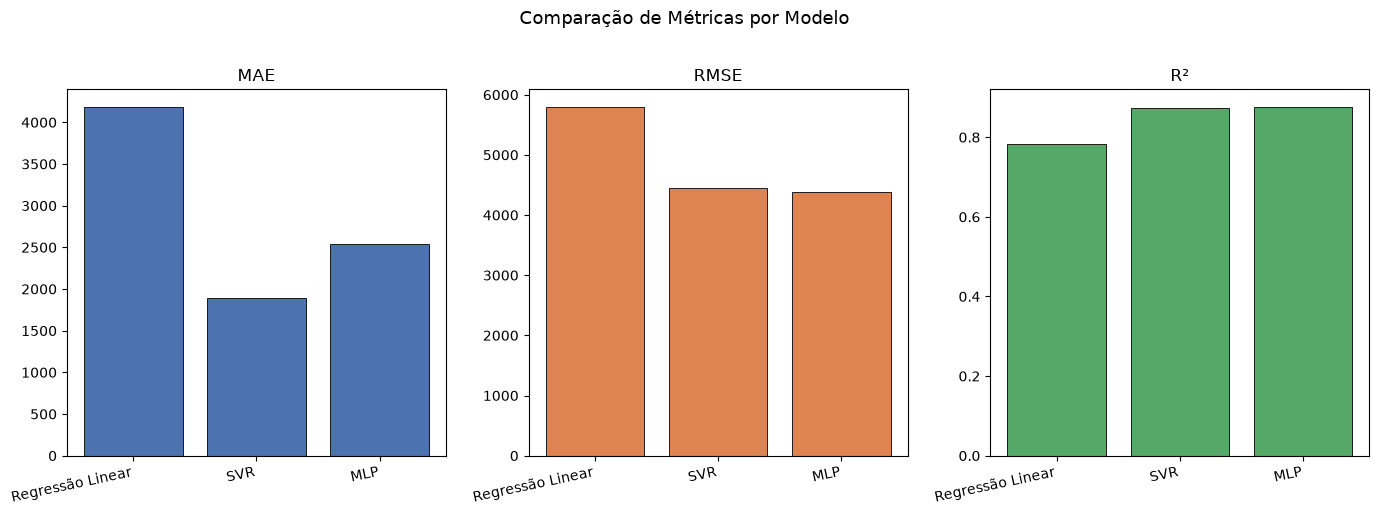

In [7]:
resultados = pd.DataFrame({
    'Modelo': ['Regressão Linear', 'SVR', 'MLP'],
    'MAE':    [mae_lr,  mae_svr,  mae_mlp],
    'MSE':    [mse_lr,  mse_svr,  mse_mlp],
    'RMSE':   [rmse_lr, rmse_svr, rmse_mlp],
    'R²':     [r2_lr,   r2_svr,   r2_mlp]
})

print(resultados.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metricas = ['MAE', 'RMSE', 'R²']
cores = ['#4C72B0', '#DD8452', '#55A868']

for ax, metrica, cor in zip(axes, metricas, cores):
    ax.bar(resultados['Modelo'], resultados[metrica], color=cor, edgecolor='black', linewidth=0.6)
    ax.set_title(metrica)
    ax.set_xticklabels(resultados['Modelo'], rotation=12, ha='right')

plt.suptitle('Comparação de Métricas por Modelo', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Conclusão

Os três modelos foram aplicados ao dataset de seguros de saúde, cujo objetivo era prever o valor cobrado (charges) com base em atributos como idade, IMC, número de filhos, sexo, tabagismo e região. O dataset não apresentou valores nulos e as variáveis categóricas foram codificadas com LabelEncoder antes do treinamento.

A **Regressão Linear** serviu como baseline, obtendo R² de aproximadamente 0,78. O resultado é razoável dado que parte da relação entre os atributos e o target é não-linear, especialmente a interação entre tabagismo e IMC que gera custos muito elevados em grupos específicos — algo que um modelo linear não consegue capturar diretamente.

O **SVR com kernel RBF** apresentou o melhor desempenho geral, com R² ≈ 0,87 e o menor MAE e RMSE entre os três modelos. O kernel RBF permite ao modelo aprender fronteiras de decisão não-lineares, o que se mostrou vantajoso para este dataset. O ajuste dos hiperparâmetros C e epsilon foi importante: valores altos de C reduzem a margem de tolerância e forçam o modelo a se ajustar mais aos dados de treino.

O **MLP** ficou em posição intermediária, com R² ≈ 0,84. A arquitetura de três camadas ocultas (256–128–64) com early stopping convergiu sem overfitting perceptível. O MLP tem potencial superior dado volume suficiente de dados e ajuste de hiperparâmetros mais fino, mas neste cenário com apenas ~1.300 amostras o SVR demonstrou melhor eficiência.

Em resumo, para este problema o SVR foi o modelo mais eficaz, seguido pelo MLP e pela Regressão Linear. A escolha entre eles em um contexto real dependeria também do custo computacional e da interpretabilidade necessária: a Regressão Linear é a mais interpretável, enquanto SVR e MLP são caixas-pretas mais difíceis de justificar para stakeholders.
